# Made by

## Name      : Anthony Djiady Djie
## Class     : Dibimbing DS39+
## Topic     : Final Project DA
## Linkedin  : www.linkedin.com/in/anthony-djiady-djie




#

# SECTION 1: Setup, Data Loading and Import Library

## 1.1 Dataset Background

* It contains transaction data from a UK-based online retailer, covering a period from December 2009 to December 2011.

## 1.2 Import Library

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import chi2_contingency
import warnings
warnings.filterwarnings('ignore')

print('Libraries imported successfully!')

Libraries imported successfully!


## 1.3 Load dataset from Google Drive


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
# Load dataset langsung dari Google Drive
df = pd.read_csv('/content/drive/MyDrive/Dibimbing DS39+/AnthonyDjiadyDjie_DS39+_Final_Project_Data_Analyst/UCI_online_retail.csv')

print('Dataset loaded successfully!')

Dataset loaded successfully!


In [ ]:
df.columns

Index(['invoice', 'stockcode', 'description', 'quantity', 'invoicedate',
       'price', 'customer_id', 'country', 'is_cancelled', 'total_price'],
      dtype='object')

## 1.4 Goals and Objective of the Data Analysis
### Customer Segmentation
Demographic, RFM Analysis, Behavior, or any kind of customer segmentation analysis


#

# SECTION 2: Data Understanding & Feature Engineering

## 2.1 Basic data inspection


In [ ]:
# Print Data Dimension
print(f"Dataset shape: {df.shape[0]} rows × {df.shape[1]} columns\n")

# Data types & nulls
print('Data Types:')
print(df.info())

# Data Summary
print('Data Summary')
print(df.describe())

# Unique counts per column
print(df.nunique())

Dataset shape: 1062989 rows × 10 columns

Data Types:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1062989 entries, 0 to 1062988
Data columns (total 10 columns):
 #   Column        Non-Null Count    Dtype  
---  ------        --------------    -----  
 0   invoice       1062989 non-null  object 
 1   stockcode     1062989 non-null  object 
 2   description   1062989 non-null  object 
 3   quantity      1062989 non-null  int64  
 4   invoicedate   1062989 non-null  object 
 5   price         1062989 non-null  float64
 6   customer_id   824364 non-null   float64
 7   country       1062989 non-null  object 
 8   is_cancelled  1062989 non-null  bool   
 9   total_price   1062989 non-null  float64
dtypes: bool(1), float64(3), int64(1), object(5)
memory usage: 74.0+ MB
None
Data Summary
           quantity         price    customer_id   total_price
count  1.062989e+06  1.062989e+06  824364.000000  1.062989e+06
mean   1.005103e+01  4.668554e+00   15324.638504  1.814436e+01
std    1.69930

### Observation:
- The 'customer_id' should be 'str' type
- The 'invoicedate' should be 'datetime' format
- There seems to be null values in the 'customer_id' column
- We don't really need much feature engineering as the 'total_price' already existed

#

## SECTION 3: EDA



## 3.1 Convert the columns to their appropriate data types.

In [ ]:
# Converting 'customer_id' to object format
df['customer_id'] = df['customer_id'].astype(str)

In [ ]:
# Converting 'invoicedate' to datetime format
df['invoicedate'] = pd.to_datetime(df['invoicedate'])

In [ ]:
# Checking if its already coverted
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1062989 entries, 0 to 1062988
Data columns (total 10 columns):
 #   Column        Non-Null Count    Dtype         
---  ------        --------------    -----         
 0   invoice       1062989 non-null  object        
 1   stockcode     1062989 non-null  object        
 2   description   1062989 non-null  object        
 3   quantity      1062989 non-null  int64         
 4   invoicedate   1062989 non-null  datetime64[ns]
 5   price         1062989 non-null  float64       
 6   customer_id   1062989 non-null  object        
 7   country       1062989 non-null  object        
 8   is_cancelled  1062989 non-null  bool          
 9   total_price   1062989 non-null  float64       
dtypes: bool(1), datetime64[ns](1), float64(2), int64(1), object(5)
memory usage: 74.0+ MB


## 3.2 Identify Column types


In [ ]:
# Identify column types
numerical_cols = df.select_dtypes(include=['float64', 'int64']).columns.tolist()
categorical_cols = df.select_dtypes(include=['object']).columns.tolist()

print('Numerical Columns:', numerical_cols)
print('\nCategorical Columns:', categorical_cols)

Numerical Columns: ['quantity', 'price', 'total_price']

Categorical Columns: ['invoice', 'stockcode', 'description', 'customer_id', 'country']


## 3.3 Identify Null value



In [ ]:
# Identify if there is empty strings in all the categorical column
categorical_cols = df.select_dtypes(include='object').columns

# Check for empty strings in each string column
empty_string_counts = {}
for col in categorical_cols:
    is_empty_string = df[col].apply(lambda x: isinstance(x, str) and len(x) == 0)
    is_nan_string = df[col].astype(str).str.lower() == 'nan'
    empty_or_nan_string_count = (is_empty_string | is_nan_string).sum()
    empty_string_counts[col] = empty_or_nan_string_count

# Display the results
for col, count in empty_string_counts.items():
    if count > 0:
        print(f"Column '{col}' contains {count} empty strings.")
    else:
        print(f"Column '{col}' contains no empty strings.")

# Identify if there is empty value in all the numerical column
for col in numerical_cols:
    zero_count = (df[col] == 0).sum()
    negative_count = (df[col] < 0).sum()
    print(f"Column '{col}': {zero_count} zeros, {negative_count} negative values")

Column 'invoice' contains no empty strings.
Column 'stockcode' contains no empty strings.
Column 'description' contains no empty strings.
Column 'customer_id' contains 238625 empty strings.
Column 'country' contains no empty strings.
Column 'quantity': 0 zeros, 20261 negative values
Column 'price': 1820 zeros, 5 negative values
Column 'total_price': 1820 zeros, 19498 negative values


### Dealing with Null Value

* We are getting rid of negative values and null values in Quantity and UnitPrice are invalid and likely due to data entry errors, so they should be removed

* We are also getting rid of null value on 'customerid' as it is very hard to track the customer (it could be a new customer or existing customer) it is very hard to identify which one is which

In [ ]:
# Drop null and negative values in price, quantity
df = df[(df['price'] > 0) & (df['quantity'] > 0)]

In [ ]:
# Drop null value in customerid
df['customer_id'] = df['customer_id'].replace('nan', np.nan)
df = df.dropna(subset=['customer_id'])

In [ ]:
# Lets recheck
print(f"Dataset shape: {df.shape[0]} rows × {df.shape[1]} columns\n")


# Check for empty strings in each string column
empty_string_counts = {}
for col in categorical_cols:
    is_empty_string = df[col].apply(lambda x: isinstance(x, str) and len(x) == 0)
    is_nan_string = df[col].astype(str).str.lower() == 'nan'
    empty_or_nan_string_count = (is_empty_string | is_nan_string).sum()
    empty_string_counts[col] = empty_or_nan_string_count

# Display the results
for col, count in empty_string_counts.items():
    if count > 0:
        print(f"Column '{col}' contains {count} empty strings.")
    else:
        print(f"Column '{col}' contains no empty strings.")

# Identify if there is empty value in all the numerical column
for col in numerical_cols:
    zero_count = (df[col] == 0).sum()
    negative_count = (df[col] < 0).sum()
    print(f"Column '{col}': {zero_count} zeros, {negative_count} negative values")

Dataset shape: 805549 rows × 10 columns

Column 'invoice' contains no empty strings.
Column 'stockcode' contains no empty strings.
Column 'description' contains no empty strings.
Column 'customer_id' contains no empty strings.
Column 'country' contains no empty strings.
Column 'quantity': 0 zeros, 0 negative values
Column 'price': 0 zeros, 0 negative values
Column 'total_price': 0 zeros, 0 negative values


## 3.4 Identify Unique Value

In [ ]:
# Unique Value for Categorical and Boolean
print('\nCategorical Variables Summary:')
for col in categorical_cols:
    print(f'{col}: {df[col].nunique()} unique values')
    print(f'  Values: {df[col].unique()}')


Categorical Variables Summary:
invoice: 36969 unique values
  Values: ['489434' '489435' '489436' ... '581585' '581586' '581587']
stockcode: 4631 unique values
  Values: ['85048' '79323P' '79323W' ... '23562' '23561' '23843']
description: 5283 unique values
  Values: ['15CM CHRISTMAS GLASS BALL 20 LIGHTS' 'PINK CHERRY LIGHTS'
 ' WHITE CHERRY LIGHTS' ... 'SILVER AND BLACK ORBIT NECKLACE'
 'CREAM HANGING HEART T-LIGHT HOLDER' 'PAPER CRAFT , LITTLE BIRDIE']
customer_id: 5878 unique values
  Values: ['13085.0' '13078.0' '15362.0' ... '15520.0' '13298.0' '12713.0']
country: 41 unique values
  Values: ['United Kingdom' 'France' 'USA' 'Belgium' 'Australia' 'EIRE' 'Germany'
 'Portugal' 'Denmark' 'Netherlands' 'Poland' 'Channel Islands' 'Spain'
 'Cyprus' 'Greece' 'Norway' 'Austria' 'Sweden' 'United Arab Emirates'
 'Finland' 'Italy' 'Switzerland' 'Japan' 'Unspecified' 'Nigeria' 'Malta'
 'RSA' 'Singapore' 'Bahrain' 'Thailand' 'Israel' 'Lithuania' 'West Indies'
 'Korea' 'Brazil' 'Canada' 'Iceland

## 3.5 Identify Duplicate

In [ ]:
# Check Duplicate as a whole
df.duplicated().sum()

np.int64(26124)

In [ ]:
# Check the Row with duplicate
df[df.duplicated(keep=False)]

,invoice,stockcode,description,quantity,invoicedate,price,customer_id,country,is_cancelled,total_price
362,489517,21913,VINTAGE SEASIDE JIGSAW PUZZLES,1,2009-12-01 11:34:00,3.75,16329.0,United Kingdom,False,3.75
363,489517,21912,VINTAGE SNAKES & LADDERS,1,2009-12-01 11:34:00,3.75,16329.0,United Kingdom,False,3.75
365,489517,21821,GLITTER STAR GARLAND WITH BELLS,1,2009-12-01 11:34:00,3.75,16329.0,United Kingdom,False,3.75
367,489517,22319,HAIRCLIPS FORTIES FABRIC ASSORTED,12,2009-12-01 11:34:00,0.65,16329.0,United Kingdom,False,7.80
368,489517,22130,PARTY CONE CHRISTMAS DECORATION,6,2009-12-01 11:34:00,0.85,16329.0,United Kingdom,False,5.10
...,...,...,...,...,...,...,...,...,...,...
1062754,581538,22068,BLACK PIRATE TREASURE CHEST,1,2011-12-09 11:34:00,0.39,14446.0,United Kingdom,False,0.39
1062768,581538,23318,BOX OF 6 MINI VINTAGE CRACKERS,1,2011-12-09 11:34:00,2.49,14446.0,United Kingdom,False,2.49
1062771,581538,22992,REVOLVER WOODEN RULER,1,2011-12-09 11:34:00,1.95,14446.0,United Kingdom,False,1.95
1062778,581538,22694,WICKER STAR,1,2011-12-09 11:34:00,2.10,14446.0,United Kingdom,False,2.10


### Dealing with Duplicates
* As we can see from the output above, the duplicates are consist of the same invoice but different items. This shows that the duplicates is caused by a person buying different items in a single purchase, thus the same invoice but different stockcode

* Therefore, we are not going to get rid of the duplicates



#


# SECTION 4: Feature Engineering

## 4.1 Finding outliers

In [ ]:
# Identify outliers from all the numerical category
# === Outlier detection using IQR method ===
outlier_summary = {}

for col in numerical_cols:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1

    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    outliers = df[(df[col] < lower_bound) | (df[col] > upper_bound)]
    outlier_summary[col] = {
        'Q1': Q1,
        'Q3': Q3,
        'IQR': IQR,
        'LowerBound': lower_bound,
        'UpperBound': upper_bound,
        'OutlierCount': len(outliers),
        'OutlierPercentage': len(outliers) / len(df) * 100
    }

outlier_df = pd.DataFrame(outlier_summary).T
outlier_df

,Q1,Q3,IQR,LowerBound,UpperBound,OutlierCount,OutlierPercentage
quantity,2.00,12.00,10.00,-13.000,27.000,51983.0,6.453115
price,1.25,3.75,2.50,-2.500,7.500,67346.0,8.360261
total_price,4.95,19.50,14.55,-16.875,41.325,66382.0,8.240591


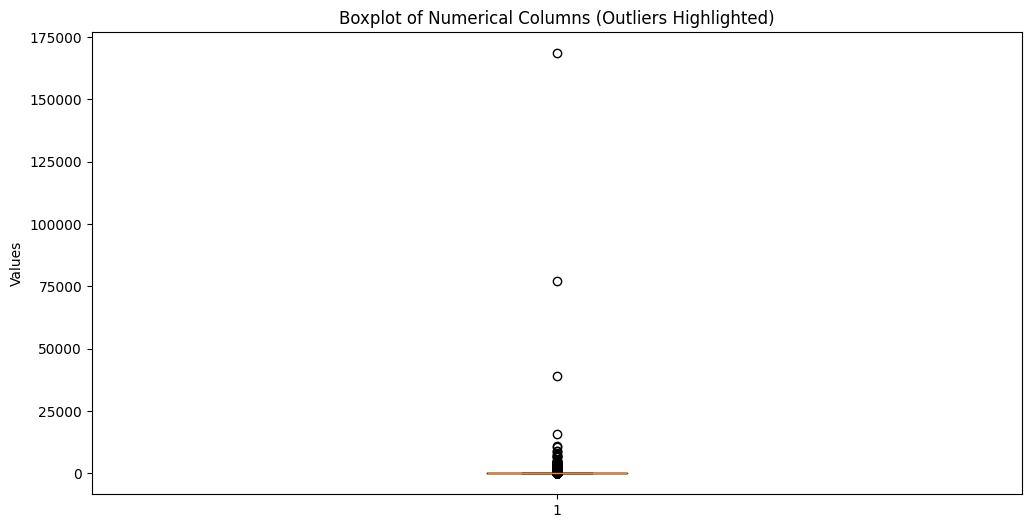

In [ ]:
# Visualisation
plt.figure(figsize=(12,6))
plt.boxplot(df['total_price'])
plt.title("Boxplot of Numerical Columns (Outliers Highlighted)")
plt.ylabel("Values")
plt.show()

In [ ]:
# Lets see how many rows are the outliers
df[df['total_price'] > 25000]

,invoice,stockcode,description,quantity,invoicedate,price,customer_id,country,is_cancelled,total_price
583991,541431,23166,MEDIUM CERAMIC TOP STORAGE JAR,74215,2011-01-18 10:01:00,1.04,12346.0,United Kingdom,False,77183.6
744339,556444,22502,PICNIC BASKET WICKER 60 PIECES,60,2011-06-10 15:28:00,649.50,15098.0,United Kingdom,False,38970.0
1061500,581483,23843,"PAPER CRAFT , LITTLE BIRDIE",80995,2011-12-09 09:15:00,2.08,16446.0,United Kingdom,False,168469.6


In [ ]:
# Lets check if it is bought by a single or multiple customers
df[df['customer_id'].isin(['12346.0', '15098.0', '16446.0'])]

,invoice,stockcode,description,quantity,invoicedate,price,customer_id,country,is_cancelled,total_price
27941,491725,TEST001,This is a test product.,10,2009-12-14 08:34:00,4.50,12346.0,United Kingdom,False,45.00
28198,491742,TEST001,This is a test product.,5,2009-12-14 11:00:00,4.50,12346.0,United Kingdom,False,22.50
28201,491744,TEST001,This is a test product.,5,2009-12-14 11:02:00,4.50,12346.0,United Kingdom,False,22.50
39317,492718,TEST001,This is a test product.,5,2009-12-18 10:47:00,4.50,12346.0,United Kingdom,False,22.50
39330,492722,TEST002,This is a test product.,1,2009-12-18 10:55:00,1.00,12346.0,United Kingdom,False,1.00
45000,493410,TEST001,This is a test product.,5,2010-01-04 09:24:00,4.50,12346.0,United Kingdom,False,22.50
45002,493412,TEST001,This is a test product.,5,2010-01-04 09:53:00,4.50,12346.0,United Kingdom,False,22.50
55806,494450,TEST001,This is a test product.,5,2010-01-14 13:50:00,4.50,12346.0,United Kingdom,False,22.50
65731,495295,TEST001,This is a test product.,5,2010-01-22 13:30:00,4.50,12346.0,United Kingdom,False,22.50
106804,499763,20682,RED SPOTTY CHILDS UMBRELLA,1,2010-03-02 13:08:00,3.25,12346.0,United Kingdom,False,3.25


In [ ]:
# Lets check how many entries are there
df[df['customer_id'].isin(['12346.0', '15098.0', '16446.0'])]['customer_id'].value_counts()

,count
customer_id,
12346.0,34
16446.0,3
15098.0,3


In [ ]:
# Drop the row where 'total_price' > 25000
df = df.drop(df[df['total_price'] > 25000].index)

In [ ]:
# Rechecking
df[df['total_price'] > 25000]

,invoice,stockcode,description,quantity,invoicedate,price,customer_id,country,is_cancelled,total_price


In [ ]:
# Checking final df
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 805546 entries, 0 to 1062988
Data columns (total 10 columns):
 #   Column        Non-Null Count   Dtype         
---  ------        --------------   -----         
 0   invoice       805546 non-null  object        
 1   stockcode     805546 non-null  object        
 2   description   805546 non-null  object        
 3   quantity      805546 non-null  int64         
 4   invoicedate   805546 non-null  datetime64[ns]
 5   price         805546 non-null  float64       
 6   customer_id   805546 non-null  object        
 7   country       805546 non-null  object        
 8   is_cancelled  805546 non-null  bool          
 9   total_price   805546 non-null  float64       
dtypes: bool(1), datetime64[ns](1), float64(2), int64(1), object(5)
memory usage: 62.2+ MB


### Dealing with outliers

#### We will remove these three entries because they are outliers in the 2009–2011 dataset. Given their rarity and potential to distort customer segmentation, eliminating them ensures more accurate and reliable analysis.

In [ ]:
# Save df
df.to_csv('AnthonyDjiadyDjie_DS39+_Final_Project_Cleaned.csv',index=False)

## 4.2 Define date for Recency

In [ ]:
# Usually we take max date + 1 day
snapshot_date = df['invoicedate'].max() + pd.Timedelta(days=1)
snapshot_date

Timestamp('2011-12-10 12:50:00')

## 4.3 RFM Metrics

In [ ]:
rfm = df.groupby('customer_id').agg({
    'invoicedate': lambda x: (snapshot_date - x.max()).days,  # Recency
    'invoice': 'nunique',                                     # Frequency
    'total_price': 'sum'                                      # Monetary
}).reset_index()

rfm.columns = ['customer_id', 'Recency', 'Frequency', 'Monetary']

## 4.4 Creating RFM Scoring

In [ ]:
# 1. Recency (lower = better)
recency_pct = rfm['Recency'].rank(pct=True)  # 0 to 1 percentile
recency_pct = 1 - recency_pct               # reverse so lower Recency = higher score

rfm['R_score'] = (
    np.select(
        [
            recency_pct <= 0.2,
            recency_pct <= 0.4,
            recency_pct <= 0.6,
            recency_pct <= 0.8,
            recency_pct > 0.8
        ],
        [1, 2, 3, 4, 5]
    )
).astype(int)


# -----------------------------
# 2. Frequency (higher = better)
# -----------------------------
freq_pct = rfm['Frequency'].rank(pct=True)

rfm['F_score'] = (
    np.select(
        [
            freq_pct <= 0.2,
            freq_pct <= 0.4,
            freq_pct <= 0.6,
            freq_pct <= 0.8,
            freq_pct > 0.8
        ],
        [1, 2, 3, 4, 5]
    )
).astype(int)


# -----------------------------
# 3. Monetary (higher = better)
# -----------------------------
monetary_pct = rfm['Monetary'].rank(pct=True)

rfm['M_score'] = (
    np.select(
        [
            monetary_pct <= 0.2,
            monetary_pct <= 0.4,
            monetary_pct <= 0.6,
            monetary_pct <= 0.8,
            monetary_pct > 0.8
        ],
        [1, 2, 3, 4, 5]
    )
).astype(int)

# Combine into final score
rfm['RFM_Score'] = (
    rfm['R_score'].astype(str) +
    rfm['F_score'].astype(str) +
    rfm['M_score'].astype(str)
)

# 4.5 Identify the Quantiles

In [ ]:
# Lets see the cutoff quantiles R
recency_table = (
    rfm.groupby('R_score')
       .agg(
           min_recency=('Recency', 'min'),
           max_recency=('Recency', 'max'),
           customers=('Recency', 'count')
       )
       .sort_index(ascending=False)
       .reset_index()
)

recency_table

,R_score,min_recency,max_recency,customers
0,5,1,19,1187
1,4,20,59,1176
2,3,60,188,1162
3,2,189,410,1177
4,1,411,739,1176


In [ ]:
# Lets see the cutoff quantiles F
frequency_table = (
    rfm.groupby('F_score')
       .agg(
           min_frequency=('Frequency', 'min'),
           max_frequency=('Frequency', 'max'),
           customers=('Frequency', 'count')
       )
       .sort_index()
       .reset_index()
)

frequency_table

,F_score,min_frequency,max_frequency,customers
0,1,1,1,1624
1,2,2,2,944
2,3,3,4,1149
3,4,5,8,1034
4,5,9,398,1127


In [ ]:
# Lets see the cutoff quantiles F
monetary_table = (
    rfm.groupby('M_score')
       .agg(
           min_monetary=('Monetary', 'min'),
           max_monetary=('Monetary', 'max'),
           customers=('Monetary', 'count')
       )
       .sort_index()
       .reset_index()
)

monetary_table

,M_score,min_monetary,max_monetary,customers
0,1,2.90,289.78,1175
1,2,289.87,617.05,1176
2,3,617.60,1246.80,1175
3,4,1247.49,2955.17,1176
4,5,2955.75,608821.65,1176


## 4.6 Create RFM Segmentation

In [ ]:
def segment(row):
    R = row['R_score']
    F = row['F_score']
    M = row['M_score']

    # 1. Current loyal high spending
    if R >= 4 and F >= 4 and M >= 4:
        return '1 Current Loyal High Spending'

    # 2. Lapsing/Inactive loyal high spending
    elif R <= 3 and F >= 4 and M >= 4:
        return '2 Lapsing/Inactive Loyal High Spending'

    # 3. Current not loyal high spending
    elif R >= 4 and F <= 3 and M >= 4:
        return '3 Current Not Loyal High Spending'

    # 4. Lapsing/Inactive not loyal high spending
    elif R <= 3 and F <= 3 and M >= 4:
        return '4 Lapsing/Inactive Not Loyal High Spending'

    # 5. Current loyal low spending
    elif R >= 4 and F >= 4 and M <= 3:
        return '5 Current Loyal Low Spending'

    # 6. Lapsing/Inactive loyal low spending
    elif R <= 3 and F >= 4 and M <= 3:
        return '6 Lapsing/Inactive Loyal Low Spending'

    # 7. Current not loyal low spending
    elif R >= 4 and F <= 3 and M <= 3:
        return '7 Current Not Loyal Low Spending'

    # 8. Lapsing/Inactive not loyal low spending
    else:
        return '8 Lapsing/Inactive Not Loyal Low Spending'

rfm['Segment'] = rfm.apply(segment, axis=1)

In [ ]:
# View the Results
rfm.head()

,customer_id,Recency,Frequency,Monetary,R_score,F_score,M_score,RFM_Score,Segment
0,12346.0,529,11,372.86,1,5,2,152,6 Lapsing/Inactive Loyal Low Spending
1,12347.0,2,8,5633.32,5,4,5,545,1 Current Loyal High Spending
2,12348.0,75,5,2019.40,3,4,4,344,2 Lapsing/Inactive Loyal High Spending
3,12349.0,19,4,4428.69,5,3,5,535,3 Current Not Loyal High Spending
4,12350.0,310,1,334.40,2,1,2,212,8 Lapsing/Inactive Not Loyal Low Spending


In [ ]:
# Save to csv
rfm.to_csv('AnthonyDjiadyDjie_DS39+_Final_Project_RFM_segmentation.csv')